In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. 載入資料與 Rank Normalization
---

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata, pearsonr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ── 路徑設定（Colab 請改成 Drive 路徑）──────────────────────────
PATH = '/content/drive/MyDrive/Kidney_Methylation/'   # 本機；Colab 改成 '/content/drive/MyDrive/Kidney_Methylation/'

def load_methyl(cg_path, eg_path):
    df_cg = pd.read_csv(cg_path, index_col=0).T
    df_eg = pd.read_csv(eg_path, index_col=0).T
    df_cg.columns = df_cg.columns.str.lower()
    df_eg.columns = df_eg.columns.str.lower()
    common = df_cg.columns.intersection(df_eg.columns)
    X = pd.concat([df_cg[common], df_eg[common]], axis=0).fillna(0)
    y = np.concatenate([np.zeros(df_cg.shape[0]), np.ones(df_eg.shape[0])])
    return X, y

def rank_norm(Xdf):
    """Per-sample rank normalization: removes cohort-level scale offsets."""
    Xv = Xdf.values.astype(float)
    out = np.array([rankdata(row) / len(row) for row in Xv])
    return pd.DataFrame(out, index=Xdf.index, columns=Xdf.columns)

X_us, y_us = load_methyl(PATH + 'usa_CG_filtered.csv', PATH + 'usa_EG_filtered.csv')
X_jp, y_jp = load_methyl(PATH + 'jp_CG_filtered.csv',  PATH + 'jp_EG_filtered.csv')

X_us_r = rank_norm(X_us)
X_jp_r = rank_norm(X_jp)

print(f'US: {X_us.shape[0]} 人, {X_us.shape[1]} CpG  |  Normal={int((y_us==0).sum())}, CKD={int((y_us==1).sum())}')
print(f'JP: {X_jp.shape[0]} 人, {X_jp.shape[1]} CpG  |  Normal={int((y_jp==0).sum())}, CKD={int((y_jp==1).sum())}')

# 2. 找兩國 DMP 一致性 CpG
---

In [ ]:
df_dmp_us = pd.read_csv(PATH + 'usa_DMP_result_TC.csv', index_col=0)
df_dmp_jp = pd.read_csv(PATH + 'jp_DMP_result_TC.csv', index_col=0)
df_deltabeta_us = pd.read_csv(PATH + 'usa_delta_beta_mean_values.csv', index_col=0)
df_deltabeta_jp = pd.read_csv(PATH + 'jp_delta_beta_mean_values.csv', index_col=0)

df_dmp_us.index = df_dmp_us.index.str.lower()
df_dmp_jp.index = df_dmp_jp.index.str.lower()
df_deltabeta_us.index = df_deltabeta_us.index.str.lower()
df_deltabeta_jp.index = df_deltabeta_jp.index.str.lower()

us_combined = df_dmp_us.join(df_deltabeta_us)
jp_combined = df_dmp_jp.join(df_deltabeta_jp)

# 顯著篩選：adj.P < 0.05, |deltaBeta| > 0.1   (人工調參)
us_sig = us_combined[
    (us_combined['N_to_C.adj.P.Val'] < 0.05) &
    (us_combined['Delta_Beta_Mean'].abs() > 0.1)
]

jp_sig = jp_combined[
    (jp_combined['N_to_C.adj.P.Val'] < 0.05) &
    (jp_combined['Delta_Beta_Mean'].abs() > 0.1)
]

common_sig = set(us_sig.index).intersection(set(jp_sig.index))
common_list = list(common_sig)
us_d = us_combined.loc[common_list, 'Delta_Beta_Mean']
jp_d = jp_combined.loc[common_list, 'Delta_Beta_Mean']

# 篩方向一致
same_dir = np.sign(us_d.values) == np.sign(jp_d.values)
concordant = np.array(common_list)[same_dir]
feats = [c for c in concordant if c in X_us_r.columns and c in X_jp_r.columns]

# 效應量相關性
r, p = pearsonr(us_d[concordant].values, jp_d[concordant].values)

print(f'US 顯著 CpG: {len(us_sig)}')
print(f'JP 顯著 CpG: {len(jp_sig)}')
print(f'兩國共同顯著: {len(common_sig)}')
print(f'方向一致（concordant）: {len(concordant)}')
print(f'兩國甲基化資料皆有: {len(feats)}')
print(f'\ndeltaBeta 相關性 (Pearson r): {r:.3f}, p={p:.2e}')
print('→ r > 0.9 代表兩國甲基化效應高度一致，訊號可信。')

### **用 LASSO 進行自動化特徵篩選(廢案)**
我們改用 `LassoCV` ，在訓練集上將兩國資料合併，以增加樣本數並尋找在不同族群中皆具備預測能力的特徵，進行合併、校正、切分與 LASSO 篩選，自動挑選最具代表性的 CpG 位點。這能確保被選中的特徵具備最強的預測能力。

In [ ]:
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

print('\n' + '='*50)
print('【嚴格外部獨立驗證：US 訓練 -> JP 測試】')
print('='*50)

# ==========================================
# 只看美國資料 (Train)
# ==========================================
# 特徵預選
pre_feats = [c for c in us_sig.index if c in X_us_r.columns and c in X_jp_r.columns]
print(f"1. US 預選特徵數 (adj.P<0.05): {len(pre_feats)}")

# 準備訓練集
X_train_us = X_us_r[pre_feats].values
y_train_us = y_us

# 標準化 (Scaler 參數必須記下來給 JP 用)
scaler = StandardScaler()
X_train_us_scaled = scaler.fit_transform(X_train_us)

# 在美國資料上跑 LASSO 精煉特徵
lasso_model = LassoCV(cv=5, random_state=42, max_iter=3000, n_jobs=-1)
lasso_model.fit(X_train_us_scaled, y_train_us)

# 找出 LASSO 係數不為 0 的特徵
lasso_selected_idx = np.where(lasso_model.coef_ != 0)[0]
final_feats = [pre_feats[i] for i in lasso_selected_idx]
print(f"2. LASSO 精煉後的最終特徵數: {len(final_feats)}")

if len(final_feats) > 0:
    # 訓練最終預測模型 (Logistic Regression)
    # 只用最終特徵重新提取與標準化
    X_train_final = X_us_r[final_feats].values
    scaler_final = StandardScaler()
    X_train_final_scaled = scaler_final.fit_transform(X_train_final)

    clf = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    clf.fit(X_train_final_scaled, y_train_us)
    print("3. 美國模型訓練完成！")

    # ==========================================
    # 解鎖日本資料 (Test)
    # ==========================================
    print("\n4. 載入日本資料進行外部盲測...")

    # 直接提取剛剛挑出的 final_feats
    X_test_jp = X_jp_r[final_feats].values
    y_test_jp = y_jp

    # 關鍵：使用美國訓練好的 scaler_final 進行轉換，不能重新 fit
    X_test_jp_scaled = scaler_final.transform(X_test_jp)

    # 進行預測
    jp_preds = clf.predict(X_test_jp_scaled)

    print(f'\nCross-cohort: Train US → Test JP (無資料洩漏版)')
    print(f'準確率: {accuracy_score(y_test_jp, jp_preds):.4f}')
    print(classification_report(y_test_jp, jp_preds, target_names=['Normal','CKD'], zero_division=0))
else:
    print("LASSO 在美國資料上未能選出有效特徵。")

## 3. 預測模型評估
---


In [ ]:
def nested_loo(X_df, y, feats, label):
    Xv = X_df[feats].values
    preds = []
    for i in range(len(y)):
        tr = [j for j in range(len(y)) if j != i]
        Xtr, ytr = Xv[tr], y[tr]
        mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-8
        clf = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
        clf.fit((Xtr - mu) / sd, ytr)
        preds.append(clf.predict(((Xv[[i]] - mu) / sd))[0])
    preds = np.array(preds)
    print(f'\n{"+"*50}')
    print(f'{label}')
    print(f'特徵數: {len(feats)}, 樣本數: {len(y)}')
    print(f'LOO-CV 準確率: {accuracy_score(y, preds):.4f}  ({int((preds==y).sum())}/{len(y)})')
    print(classification_report(y, preds, target_names=['Normal','CKD'], zero_division=0))
    return preds

# def cross_cohort(X_tr_df, y_tr, X_te_df, y_te, feats, label):                 # Data Leakage!!
#     Xtr = X_tr_df[feats].values
#     Xte = X_te_df[feats].values
#     mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-8
#     clf = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
#     clf.fit((Xtr - mu) / sd, y_tr)
#     preds = clf.predict((Xte - mu) / sd)
#     print(f'\n{"+"*50}')
#     print(f'{label}')
#     print(f'特徵數: {len(feats)}, 訓練: {len(y_tr)}, 測試: {len(y_te)}')
#     print(f'準確率: {accuracy_score(y_te, preds):.4f}  ({int((preds==y_te).sum())}/{len(y_te)})')
#     print(classification_report(y_te, preds, target_names=['Normal','CKD'], zero_division=0))
#     return preds

print('=' * 50)
print('模型：Logistic Regression (C=0.1)')
print('特徵：兩國 DMP 一致性 CpG（adj.P<0.05, |ΔBeta|>0.1, 方向一致）')
print('前處理：Per-sample rank normalization')
print('=' * 50)

nested_loo(X_us_r, y_us, feats, 'Within-US  Nested LOO-CV')
nested_loo(X_jp_r, y_jp, feats, 'Within-JP  Nested LOO-CV')
# cross_cohort(X_us_r, y_us, X_jp_r, y_jp, feats, 'Cross-cohort: Train US → Test JP')   # Data Leakage!!
# cross_cohort(X_jp_r, y_jp, X_us_r, y_us, feats, 'Cross-cohort: Train JP → Test US')   # Data Leakage!!

###3.1  驗證及優化.

---   



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle

print('\n' + '='*50)
print('\n---Step 1: Strict External Validation---')
print('='*50)

# 確保索引與欄位名稱皆為小寫以利比對
us_combined.index = us_combined.index.str.lower()
X_us_r.columns = X_us_r.columns.str.lower()
X_jp_r.columns = X_jp_r.columns.str.lower()

# 只從美國資料中挑選特徵
strict_us_sig = us_combined[
    (us_combined['N_to_C.adj.P.Val'] < 0.05) &
    (us_combined['Delta_Beta_Mean'].abs() > 0.1)
].sort_values('N_to_C.adj.P.Val')

# 取得前 30 個，並確保這些探針在兩國資料中都存在
potential_feats = strict_us_sig.index.tolist()
strict_feats = [c for c in potential_feats if c in X_us_r.columns and c in X_jp_r.columns][:30]

print(f"根據美國資料篩選，且兩國資料皆有的特徵數: {len(strict_feats)}")

# 訓練集標準化
X_train_strict = X_us_r[strict_feats].values
y_train_strict = y_us

mu_strict = X_train_strict.mean(0)
sd_strict = X_train_strict.std(0) + 1e-8
X_train_strict_scaled = (X_train_strict - mu_strict) / sd_strict

# 訓練模型 (完全只用美國資料)
strict_clf = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
strict_clf.fit(X_train_strict_scaled, y_train_strict)

# 外部驗證 (使用美國的 mu/sd)
X_test_strict = X_jp_r[strict_feats].values
y_test_strict = y_jp

X_test_strict_scaled = (X_test_strict - mu_strict) / sd_strict

# 進行預測
strict_preds = strict_clf.predict(X_test_strict_scaled)

print(f'\nCross-cohort: Train US → Test JP (No Data Leakage)')
print(f'準確率: {accuracy_score(y_test_strict, strict_preds):.4f}')
print(classification_report(y_test_strict, strict_preds, target_names=['Normal','CKD'], zero_division=0))


print('\n' + '='*50)
print("\n--- Step 2: Y-Randomization (LOOCV, 100 iterations) ---")
print('\n' + '='*50)

def y_randomization(X_df, y, feature_list, n_iters=100):
    if len(feature_list) == 0:
        print("No features provided for Y-randomization.")
        return
    null_accuracies = []
    Xv = X_df[feature_list].values
    for _ in range(n_iters):
        y_shuffled = shuffle(y, random_state=None)
        preds = []
        for i in range(len(y_shuffled)):
            tr = [j for j in range(len(y_shuffled)) if j != i]
            clf = LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced')
            mu, sd = Xv[tr].mean(0), Xv[tr].std(0) + 1e-8
            clf.fit((Xv[tr] - mu) / sd, y_shuffled[tr])
            preds.append(clf.predict((Xv[[i]] - mu) / sd)[0])
        null_accuracies.append(accuracy_score(y_shuffled, preds))
    print(f"Mean Random Accuracy: {np.mean(null_accuracies):.4f}")
    print(f"Max Random Accuracy: {np.max(null_accuracies):.4f}")

print("====================US====================")
y_randomization(X_us_r, y_us, feats)
print("====================JP====================")
y_randomization(X_jp_r, y_jp, feats)

# --- Non-linear Model (Random Forest) ---
print("\n--- Step 3: Random Forest Cross-Cohort Evaluation ---")
def cross_cohort_rf(X_tr_df, y_tr, X_te_df, y_te, feats, label):
    clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
    clf.fit(X_tr_df[feats], y_tr)
    preds = clf.predict(X_te_df[feats])
    acc = accuracy_score(y_te, preds)
    print(f"{label} (RF) Accuracy: {acc:.4f}")

cross_cohort_rf(X_us_r, y_us, X_jp_r, y_jp, feats, 'US -> JP')

# 4. 一致性 CpG → 基因 → Enrichr(找共病基因)
---

In [ ]:
gene_col = 'N_to_C.gene'

# 摘要表
summary = pd.DataFrame({
    'CpG':          feats,
    'US_deltaBeta': df_dmp_us.loc[feats, 'N_to_C.deltaBeta'].values,
    'US_adjP':      df_dmp_us.loc[feats, 'N_to_C.adj.P.Val'].values,
    'JP_deltaBeta': df_dmp_jp.loc[feats, 'N_to_C.deltaBeta'].values,
    'JP_adjP':      df_dmp_jp.loc[feats, 'N_to_C.adj.P.Val'].values,
    'Gene':         df_dmp_us.loc[feats, gene_col].values,
}).sort_values('US_adjP')

print(f'一致性 CpG 摘要（共 {len(summary)} 個）')
print(summary.to_string(index=False))

# Enrichr 基因清單
genes = (
    summary['Gene'].dropna()
    .apply(lambda x: str(x).split(';')[0].strip())
    .unique().tolist()
)
genes = [g for g in genes if g and g != 'nan']

print(f'\n對應基因數: {len(genes)}')
print('\n' + '='*40)
print('Enrichr 輸入基因清單')
print('='*40)
for g in genes:
    print(g)

# 儲存
# summary.to_csv(PATH + 'concordant_CpGs.csv', index=False)
# with open(PATH + 'enrichr_genes.txt', 'w') as f:
#     f.write('\n'.join(genes))

# 5.　兩國差異的CpG位點 → 基因(找差異)

In [ ]:
us_sig_list = us_sig.index.tolist()
jp_sig_list = jp_sig.index.tolist()

# 差集
us_specific_cpgs = list(set(us_sig_list) - set(jp_sig_list))
jp_specific_cpgs = list(set(jp_sig_list) - set(us_sig_list))

print(f"美國特有的致病 CpG 數量: {len(us_specific_cpgs)}")
print(f"日本特有的致病 CpG 數量: {len(jp_specific_cpgs)}")

# 從這些特有探針中，萃取出所有不重複且非 NaN 的「基因清單」
def get_clean_genes(df, cpg_list):
    genes = df.loc[cpg_list, 'N_to_C.gene'].dropna().astype(str)
    # 處理 'GeneA;GeneB' 的情況，只取第一個
    clean_genes = [g.split(';')[0].strip() for g in genes if g.strip() != 'nan']
    return list(set(clean_genes)) # 取 unique

us_specific_genes = get_clean_genes(us_sig, us_specific_cpgs)
jp_specific_genes = get_clean_genes(jp_sig, jp_specific_cpgs)

print()
print(f"萃取出的美國特有基因數量: {len(us_specific_genes)}")
print(f"萃取出的日本特有基因數量: {len(jp_specific_genes)}")

In [ ]:
!pip install gseapy


### 5.1 Enrichr 功能富集分析 (GSEApy)
我們針對以下三組清單進行生物功能探討：
1. **Concordant**: 兩國方向一致的 28 個基因。
2. **US-Specific**: 美國特有顯著基因。
3. **JP-Specific**: 日本特有顯著基因。



--- 正在執行: Concordant Genes (31 CpGs) ---
uhh... 沒有 Adjusted P-value < 0.05 的顯著通路。

--- 正在執行: US-Specific Genes ---


,Gene_set,Term,Overlap,Adjusted P-value
0,GO_Biological_Process_2026,Axon Guidance (GO:0007411),112/158,0.006176
1,GO_Biological_Process_2026,Cell Surface Receptor Protein Tyrosine Kinase ...,194/297,0.006287
2,GO_Biological_Process_2026,Regulation of Small GTPase Mediated Signal Tra...,114/164,0.006287
3,GO_Biological_Process_2026,Neuron Projection Guidance (GO:0097485),98/138,0.006287
4,GO_Biological_Process_2026,Regulation of Signal Transduction (GO:0009966),155/235,0.012433
5,GO_Biological_Process_2026,Regulation of Neuron Projection Development (G...,121/179,0.016896
6,GO_Biological_Process_2026,Epithelial Cell Development (GO:0002064),25/28,0.028386
7,GO_Biological_Process_2026,Non-canonical Wnt Signaling Pathway (GO:0035567),37/46,0.043621
8,GO_Biological_Process_2026,Regulation of Stress Fiber Assembly (GO:0051492),55/74,0.043621
9,GO_Biological_Process_2026,Cell-matrix Adhesion (GO:0007160),81/116,0.043621


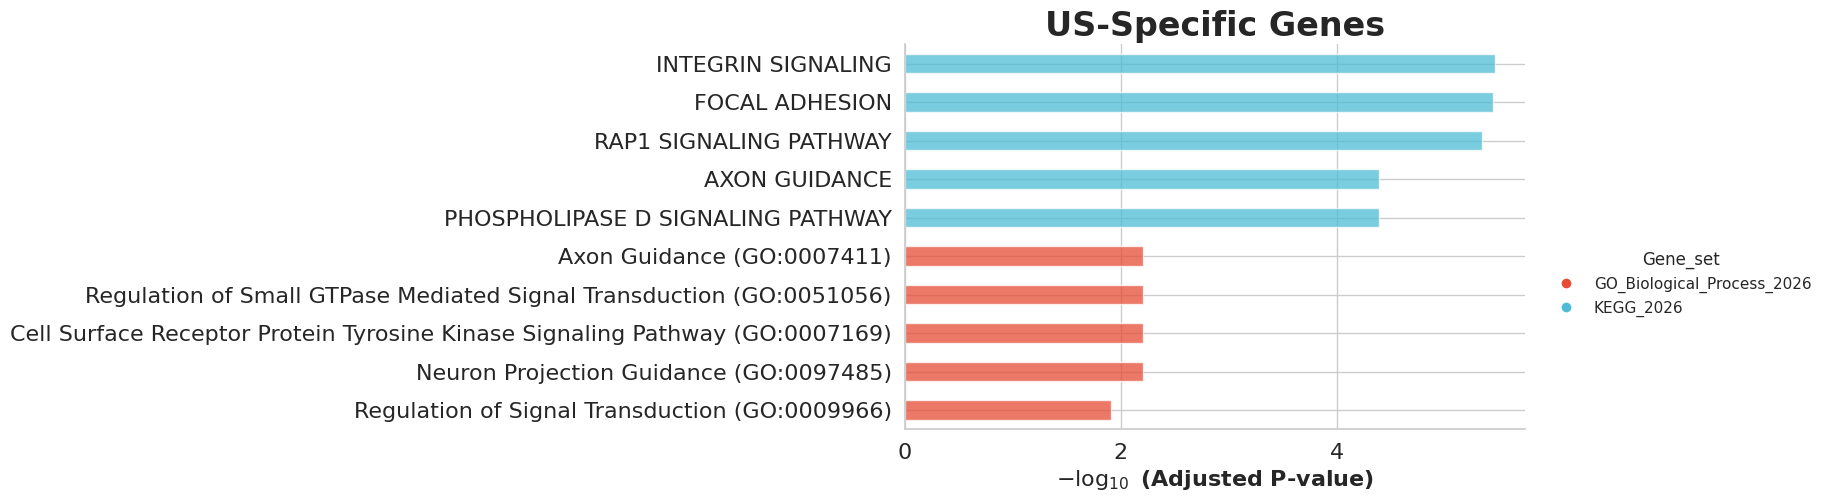


--- 正在執行: JP-Specific Genes ---


,Gene_set,Term,Overlap,Adjusted P-value
0,GO_Biological_Process_2026,Regulation of Plasma Membrane Bounded Cell Pro...,14/78,0.024510
1,GO_Biological_Process_2026,Response to Glucose (GO:0009749),11/51,0.024510
2,GO_Biological_Process_2026,Neutral Lipid Catabolic Process (GO:0046461),4/5,0.024510
3,GO_Biological_Process_2026,Positive Regulation of Cell Migration (GO:0030...,35/349,0.024510
4,GO_Biological_Process_2026,Insulin Receptor Signaling Pathway (GO:0008286),11/54,0.024510
5,GO_Biological_Process_2026,Cell Surface Receptor Protein Tyrosine Kinase ...,31/297,0.024510
6,GO_Biological_Process_2026,Regulation of Cell Migration (GO:0030334),43/484,0.035761
7,GO_Biological_Process_2026,Pos Reg Phosphatidylinositol 3-Kinase/Protein ...,21/173,0.035761
8,GO_Biological_Process_2026,Regulation of Glycolytic Process (GO:0006110),10/49,0.035761
3550,KEGG_2026,RAP1 SIGNALING PATHWAY,26/210,0.002862


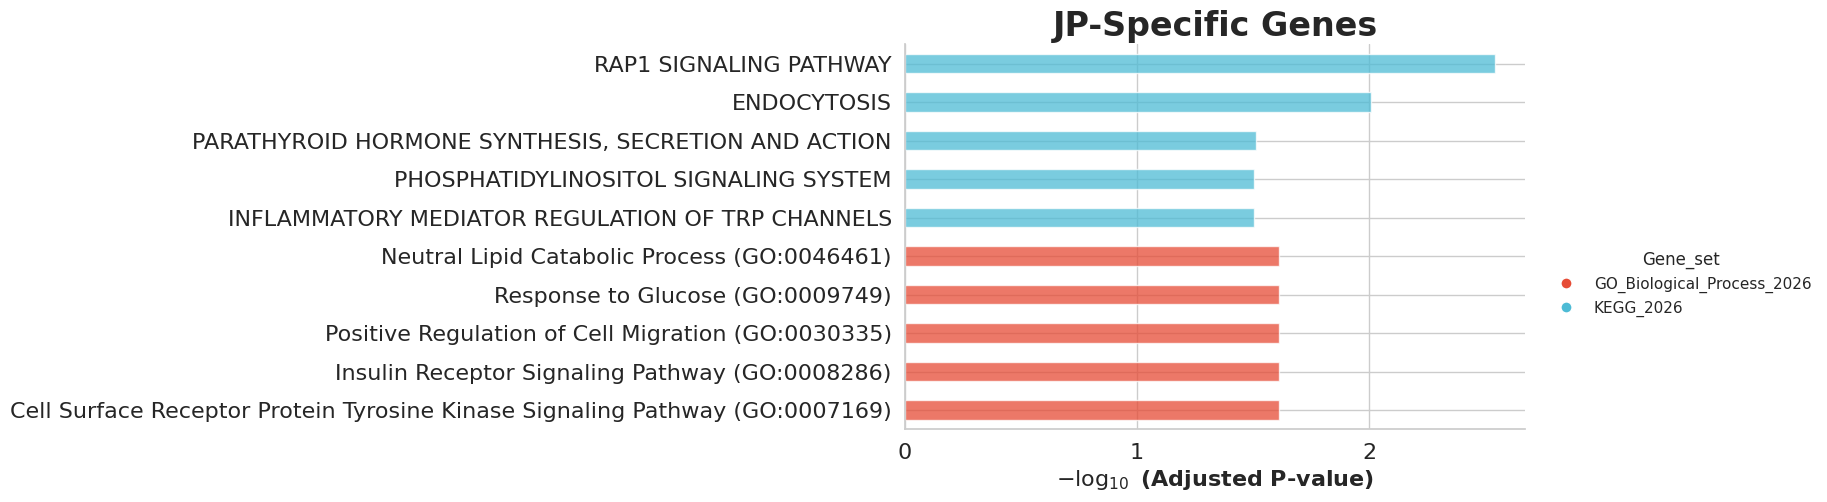

In [ ]:
import gseapy as gp
import matplotlib.pyplot as plt
from gseapy import barplot

def run_enrichr_custom(gene_list, title):
    print(f"\n--- 正在執行: {title} ---")
    if not gene_list or len(gene_list) < 5:
        print("基因清單過少，跳過分析。")
        return None

    # 執行 Enrichr 查詢，更新至 2026 版本
    enr = gp.enrichr(gene_list=gene_list,
                     gene_sets=['GO_Biological_Process_2026', 'KEGG_2026'],
                     organism='human',
                     outdir=None)

    if enr.results.empty:
        print("無富集結果。")
        return enr

    # 只抓取 Adjusted P-value < 0.05 的「真正顯著」通路
    sig_results = enr.results[enr.results['Adjusted P-value'] < 0.05]

    if sig_results.empty:
        print("uhh... 沒有 Adjusted P-value < 0.05 的顯著通路。")
    else:
        display(sig_results[['Gene_set', 'Term', 'Overlap', 'Adjusted P-value']].head(10))

        # 繪圖
        try:
            ax = barplot(enr.results,
                         column="Adjusted P-value",
                         group='Gene_set',
                         size=10,
                         top_term=5,
                         cutoff=0.05,
                         figsize=(8, 5),
                         title=title,
                         color=['#E64B35', '#4DBBD5'])
            plt.show()
        except Exception as e:
            print(f"繪圖失敗: {e}")

    return enr

# 執行分析 (丟入完整的基因清單)
enr_concordant = run_enrichr_custom(genes, "Concordant Genes (31 CpGs)")
enr_us = run_enrichr_custom(us_specific_genes, "US-Specific Genes")
enr_jp = run_enrichr_custom(jp_specific_genes, "JP-Specific Genes")



### 5.2 致病 CpG 位點出現理由深度解析 (31 個一致性位點)

這 31 個位點在不同種族（美國與日本）中均顯示出高度一致的甲基化變化趨勢，代表了 CKD 發展過程中的**核心病理機制**。以下是關鍵基因的致病理由分析：

### 1. 屏障功能受損 (Barrier Dysfunction)
* **相關基因**: `CGN` (Cingulin), `CGNL1` (Cingulin-like 1), `PARD6G-AS1`
* **致病理由**: 這些基因編碼緊密連接（Tight Junction）蛋白。在 CKD 中，這些位點發生甲基化異常會導致腎小管上皮細胞之間的屏障失靈，引發蛋白尿與組織間質水腫。

### 2. 細胞極性與結構重建 (Cell Polarity & Remodeling)
* **相關基因**: `PLEC1` (Plectin), `BAIAP2`, `CLIP1`
* **致病理由**: 腎臟受損時，足細胞（Podocytes）會發生細胞骨架重組。`PLEC1` 是維持細胞機械強度的關鍵，其甲基化改變反映了細胞在面對壓力時的結構退化或纖維化前兆。

### 3. 代謝壓力與氧化損傷 (Metabolic Stress & Oxidative Damage)
* **相關基因**: `IDH2` (Isocitrate Dehydrogenase 2), `NFE2L1`
* **致病理由**: `IDH2` 是線粒體內保護細胞免受氧化應備受損的重要酶。其 CpG 位點的改變通常是為了應對「蛋白質變質」產生的活性氧（ROS），代表細胞正在嘗試調節代謝門檻以生存。

### 4. 溶質運輸與毒素排除異常 (Solute Transport)
* **相關基因**: `SLC43A2`, `PTH1R` (副甲狀腺素受體)
* **致病理由**: `SLC43A2` 負責氨基酸轉運，`PTH1R` 調節磷酸鹽代謝。這些位點的甲基化異常直接導致腎臟排水排毒功能下降，是 CKD 生化指標異常的表觀遺傳根源。


In [ ]:
# 自動判斷調控方向 (正值為 Hyper，負值為 Hypo)
summary['US_Status'] = summary['US_deltaBeta'].apply(lambda x: 'Hyper-methylated' if x > 0 else 'Hypo-methylated')
summary['JP_Status'] = summary['JP_deltaBeta'].apply(lambda x: 'Hyper-methylated' if x > 0 else 'Hypo-methylated')

# 根據生物學常識推導基因表現預測
def infer_regulation(row):
    if row['US_Status'] == 'Hyper-methylated':
        return '可能被抑制 (Potentially Silenced / Down-regulated)'
    else:
        return '可能被激活 (Potentially Activated / Up-regulated)'

summary['Predicted_Expression'] = summary.apply(infer_regulation, axis=1)

# 建立更詳細的基因理由摘要表
reason_map = {
    'SLC43A2': '氨基酸轉運調節，反映腎小管重吸收功能受損',
    'CGN': '緊密連接蛋白，負責上皮屏障完整性',
    'CGNL1': '調節細胞間黏附，防止蛋白尿洩漏',
    'IDH2': '線粒體抗氧化壓力，應對細胞內受損蛋白積聚',
    'PLEC1': '細胞骨架穩定性，與腎小管纖維化高度相關',
    'NFE2L1': '轉錄因子，啟動蛋白質分解與抗氧化防禦系統',
    'PTH1R': '副甲狀腺素受體，調節鈣磷平衡與骨腎軸心',
    'BAIAP2': '調節細胞膜突起，影響足細胞過濾功能'
}
summary['Functional_Reason'] = summary['Gene'].map(reason_map).fillna('涉及細胞應急與基因調控網路')

print("【自動推導 31 個致病位點調控方向與機制摘要】")
display(summary[['CpG', 'Gene', 'US_Status', 'Predicted_Expression', 'Functional_Reason']].head(15))

【自動推導 31 個致病位點調控方向與機制摘要】


,CpG,Gene,US_Status,Predicted_Expression,Functional_Reason
6,cg12293460,SLC43A2,Hyper-methylated,可能被抑制 (Potentially Silenced / Down-regulated),氨基酸轉運調節，反映腎小管重吸收功能受損
12,cg10054569,NaN,Hyper-methylated,可能被抑制 (Potentially Silenced / Down-regulated),涉及細胞應急與基因調控網路
17,cg12315900,CLIP1,Hyper-methylated,可能被抑制 (Potentially Silenced / Down-regulated),涉及細胞應急與基因調控網路
5,cg08340838,OR2B3,Hyper-methylated,可能被抑制 (Potentially Silenced / Down-regulated),涉及細胞應急與基因調控網路
23,cg02692177,NaN,Hyper-methylated,可能被抑制 (Potentially Silenced / Down-regulated),涉及細胞應急與基因調控網路
1,cg19437852,EPN1,Hyper-methylated,可能被抑制 (Potentially Silenced / Down-regulated),涉及細胞應急與基因調控網路
13,cg01943179,LPCAT1,Hyper-methylated,可能被抑制 (Potentially Silenced / Down-regulated),涉及細胞應急與基因調控網路
7,cg21646082,CCDC21,Hyper-methylated,可能被抑制 (Potentially Silenced / Down-regulated),涉及細胞應急與基因調控網路
19,cg02823530,IDH2,Hyper-methylated,可能被抑制 (Potentially Silenced / Down-regulated),線粒體抗氧化壓力，應對細胞內受損蛋白積聚
20,cg23037321,MR1,Hypo-methylated,可能被激活 (Potentially Activated / Up-regulated),涉及細胞應急與基因調控網路


### 5.3 雙世代效應量對照散佈圖

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.set_theme(style="whitegrid")

# 繪製散佈圖與回歸趨勢線
sns.regplot(
    data=summary, x='US_deltaBeta', y='JP_deltaBeta',
    color='#2C3E50', marker='o',
    scatter_kws={'s': 60, 'alpha': 0.8, 'edgecolor': 'w', 'linewidths': 0.5},
    line_kws={'color': '#E74C3C', 'lw': 1.5, 'linestyle': '--'}
)

# 畫出十字象限輔助線 (y=0 和 x=0)
plt.axhline(0, color='gray', linestyle=':', alpha=0.6)
plt.axvline(0, color='gray', linestyle=':', alpha=0.6)

# 標註相關性係數
plt.text(
    0.05, 0.95, f'Pearson $r$ = {r:.3f}\n$p$ = {p:.2e}',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='0.8')
)

plt.title('Cross-Cohort Effect Size Correlation (Concordant CpGs)', fontsize=13, pad=15)
# 使用 raw string (r'...') 解決 LaTeX 轉義問題
plt.xlabel(r'US $\Delta\beta$ (Case - Normal)', fontsize=11)
plt.ylabel(r'JP $\Delta\beta$ (Case - Normal)', fontsize=11)
plt.tight_layout()
plt.show()




### 5.4 KEGG & GO BP圖表
我們將針對「一致性基因 (Concordant Genes)」、「美國與日本各自特有的前 30 名顯著基因」進行視覺化。左側為 KEGG 2026，右側為 GO Biological Process 2026。

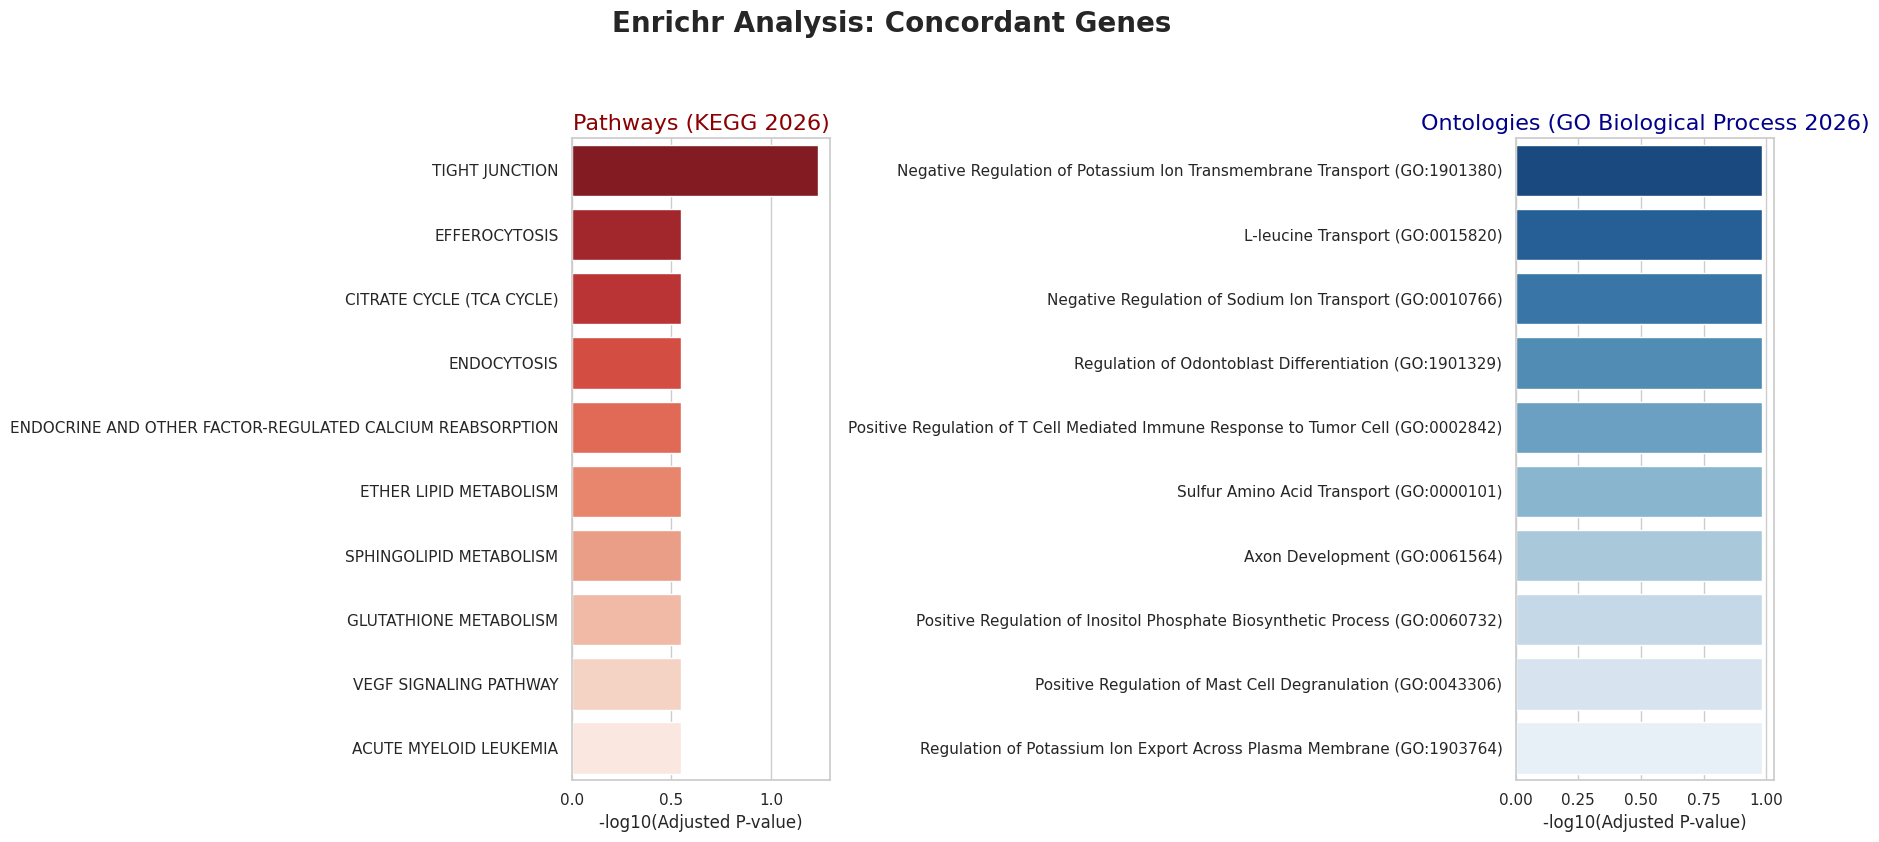

--- US-Specific Genes 視覺化 ---


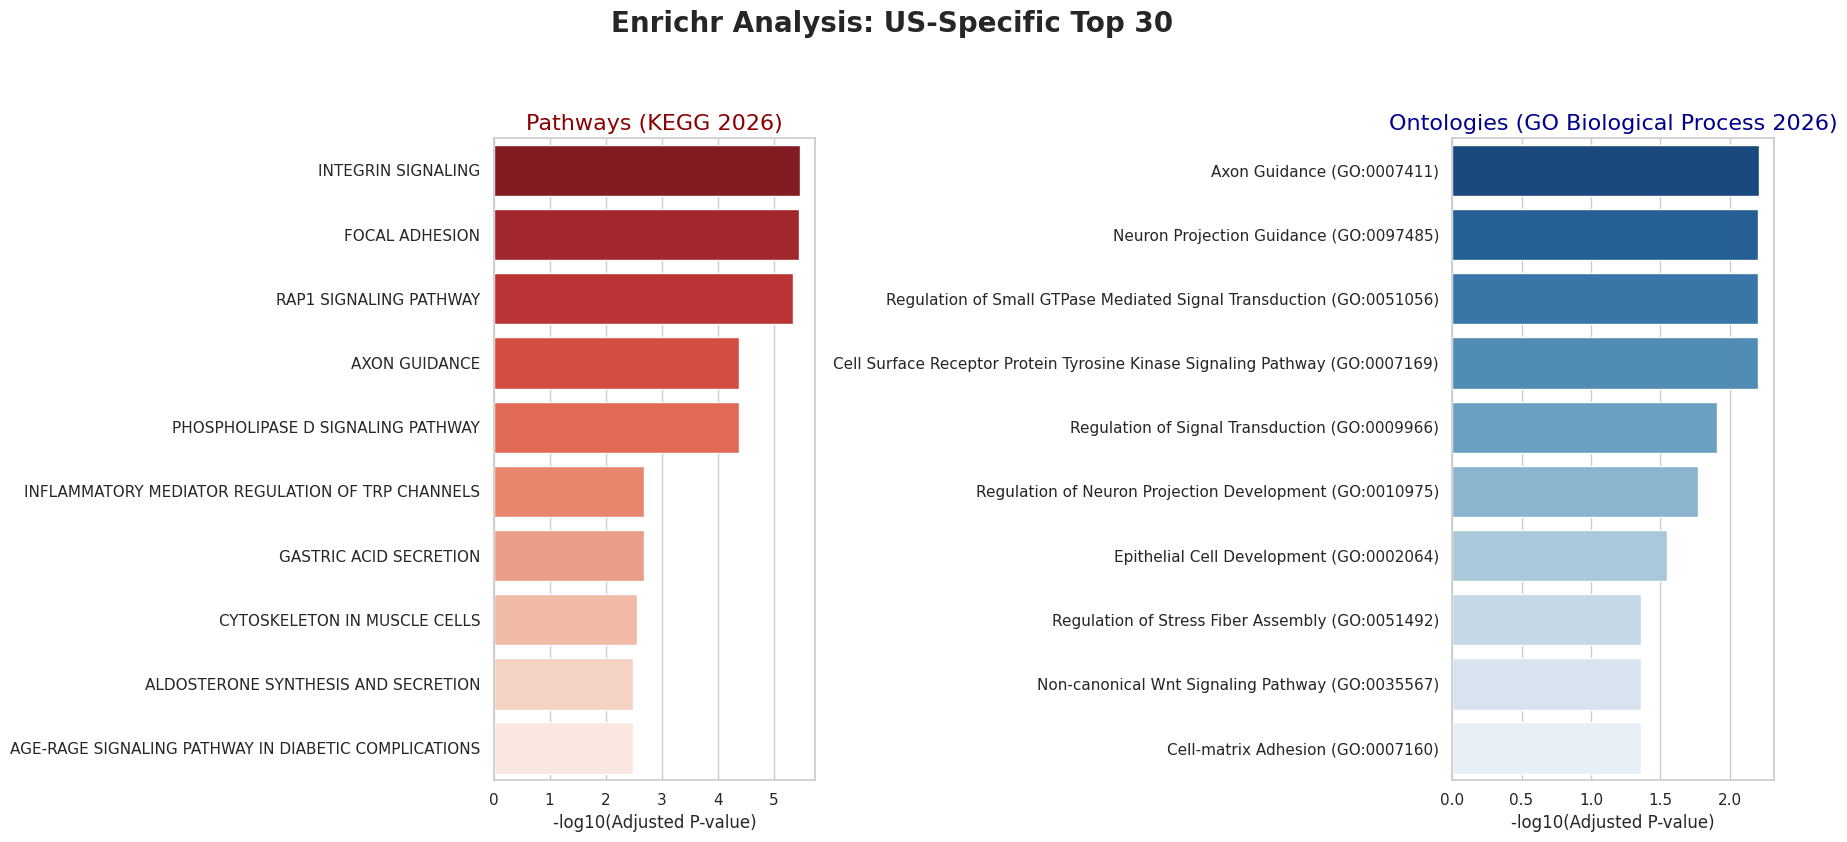


--- JP-Specific Genes 視覺化 ---


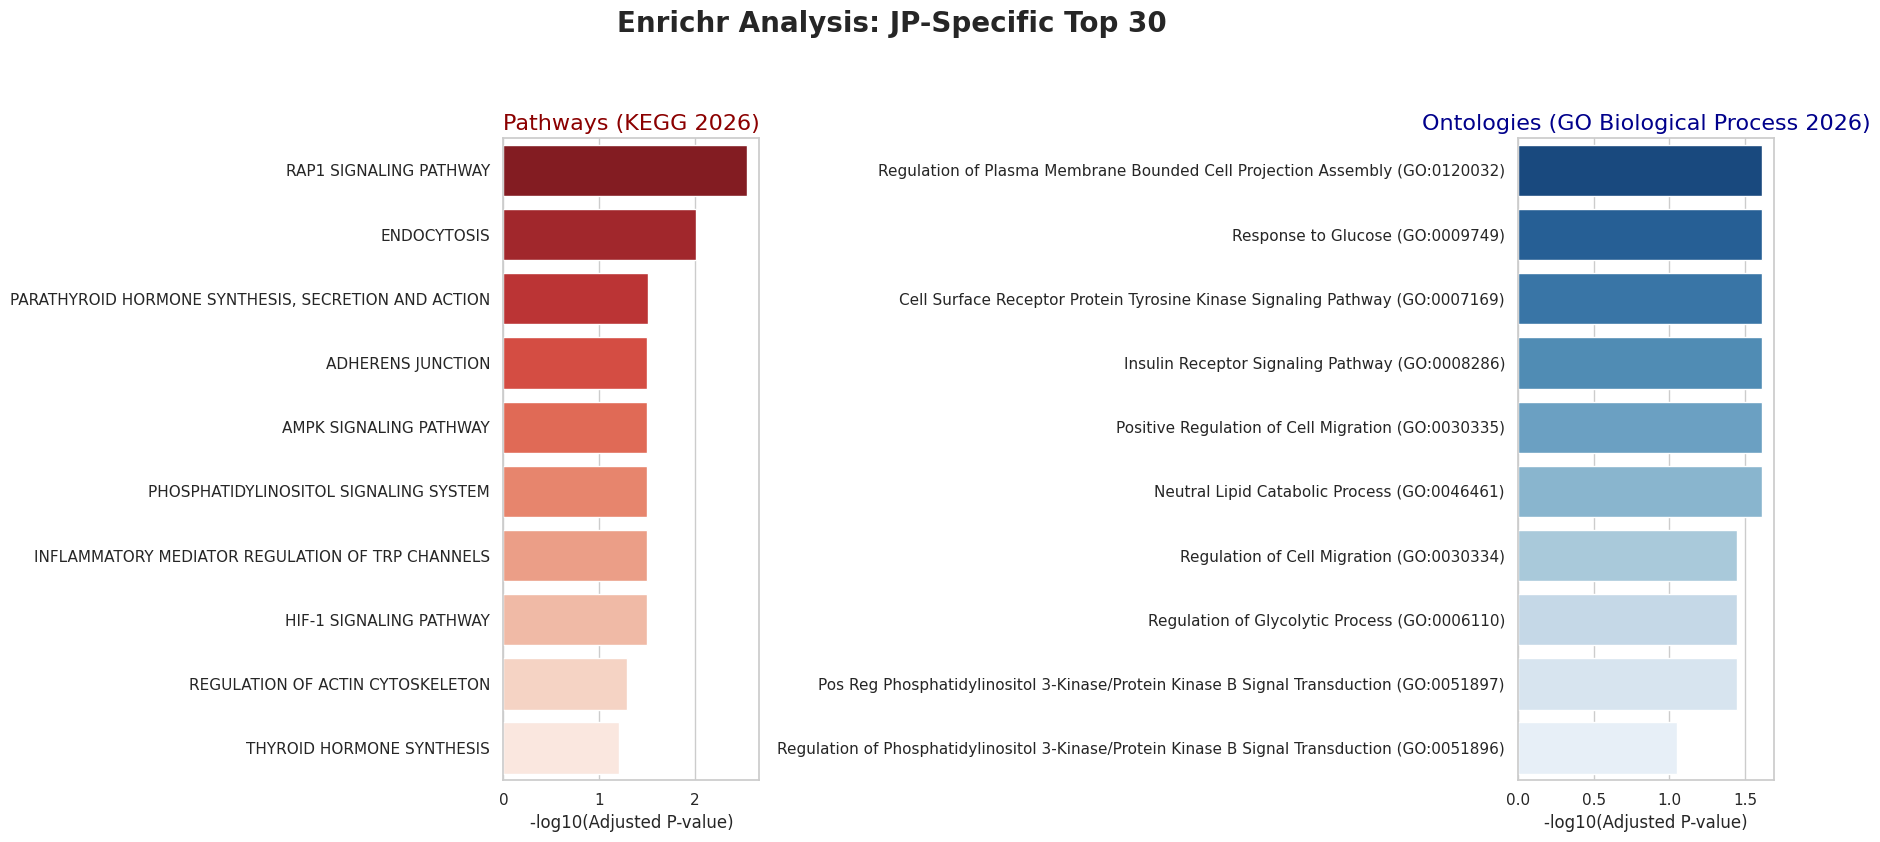

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_enrichr_style(enr_obj, title_main):
    if enr_obj is None or enr_obj.results.empty:
        print("無分析結果可繪製。")
        return

    # 提取資料
    res = enr_obj.results.copy()
    res['-log10(Adj.P)'] = -np.log10(res['Adjusted P-value'] + 1e-10)

    # 篩選對應的 2026 版本結果
    kegg = res[res['Gene_set'] == 'KEGG_2026'].sort_values('-log10(Adj.P)', ascending=False).head(10)
    go_bp = res[res['Gene_set'] == 'GO_Biological_Process_2026'].sort_values('-log10(Adj.P)', ascending=False).head(10)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f"Enrichr Analysis: {title_main}", fontsize=20, fontweight='bold', y=1.05)

    # Plot KEGG
    if not kegg.empty:
        sns.barplot(x='-log10(Adj.P)', y='Term', data=kegg, ax=axes[0], palette='Reds_r', hue='Term', legend=False)
        axes[0].set_title('Pathways (KEGG 2026)', fontsize=16, color='darkred')
        axes[0].set_xlabel('-log10(Adjusted P-value)', fontsize=12)
        axes[0].set_ylabel('')
    else:
        axes[0].text(0.5, 0.5, 'No Significant KEGG 2026 results', ha='center')

    # Plot GO BP
    if not go_bp.empty:
        sns.barplot(x='-log10(Adj.P)', y='Term', data=go_bp, ax=axes[1], palette='Blues_r', hue='Term', legend=False)
        axes[1].set_title('Ontologies (GO Biological Process 2026)', fontsize=16, color='darkblue')
        axes[1].set_xlabel('-log10(Adjusted P-value)', fontsize=12)
        axes[1].set_ylabel('')
    else:
        axes[1].text(0.5, 0.5, 'No Significant GO BP 2026 results', ha='center')

    plt.tight_layout()
    plt.show()

# 執行繪圖
plot_enrichr_style(enr_concordant, "Concordant Genes")

print("--- US-Specific Genes 視覺化 ---")
plot_enrichr_style(enr_us, "US-Specific Top 30")

print("\n--- JP-Specific Genes 視覺化 ---")
plot_enrichr_style(enr_jp, "JP-Specific Top 30")

### 5.5 Publication-Ready 條件著色表格與 GeneCards 超連結

In [ ]:
from IPython.display import HTML

def make_clickable(gene_name):
    if pd.isna(gene_name) or str(gene_name) == 'nan':
        return 'N/A'
    # 處理多個基因的情況，只取第一個產生網址
    pure_gene = str(gene_name).split(';')[0].strip()
    url = f"https://www.genecards.org/cgi-bin/carddisp.pl?gene={pure_gene}"
    return f'<a href="{url}" target="_blank">{gene_name}</a>'

# 建立用於展示的 DataFrame 副本
display_df = summary[['CpG', 'Gene', 'US_deltaBeta', 'JP_deltaBeta', 'Predicted_Expression']].copy()

# 將基因名稱轉換為超連結
display_df['Gene'] = display_df['Gene'].apply(make_clickable)

# 套用顏色漸層樣式 (數值越大越紅，越小越藍)
styled_table = (
    display_df.style
    .background_gradient(cmap='bwr', subset=['US_deltaBeta', 'JP_deltaBeta'], vmin=-0.3, vmax=0.3)
    .format({'US_deltaBeta': '{:.4f}', 'JP_deltaBeta': '{:.4f}'})
    .set_caption("Table 1: Comprehensive Annotation of Cross-Cohort Concordant CpG Sites")
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
)

# 在 Notebook 中動態渲染這張精美表格
HTML(styled_table.to_html(escape=False))

,CpG,Gene,US_deltaBeta,JP_deltaBeta,Predicted_Expression
6,cg12293460,SLC43A2,0.1122,0.2190,可能被抑制 (Potentially Silenced / Down-regulated)
12,cg10054569,N/A,0.1333,0.2183,可能被抑制 (Potentially Silenced / Down-regulated)
17,cg12315900,CLIP1,0.1489,0.2326,可能被抑制 (Potentially Silenced / Down-regulated)
5,cg08340838,OR2B3,0.0993,0.1403,可能被抑制 (Potentially Silenced / Down-regulated)
23,cg02692177,N/A,0.1264,0.2242,可能被抑制 (Potentially Silenced / Down-regulated)
1,cg19437852,EPN1,0.1410,0.2116,可能被抑制 (Potentially Silenced / Down-regulated)
13,cg01943179,LPCAT1,0.1267,0.2200,可能被抑制 (Potentially Silenced / Down-regulated)
7,cg21646082,CCDC21,0.1812,0.2763,可能被抑制 (Potentially Silenced / Down-regulated)
19,cg02823530,IDH2,0.1164,0.2537,可能被抑制 (Potentially Silenced / Down-regulated)
20,cg23037321,MR1,-0.1060,-0.2439,可能被激活 (Potentially Activated / Up-regulated)


# 6. 視覺化一致性 CpG 的甲基化分佈
我們使用熱圖 (Heatmap) 來觀察這 31 個 CpG 位點在兩國樣本中的表現。由於資料已經過 Rank Normalization，數值介於 0 到 1 之間。


--- 繪製雙世代聯合熱圖 (Cross-Cohort Mega Heatmap) ---


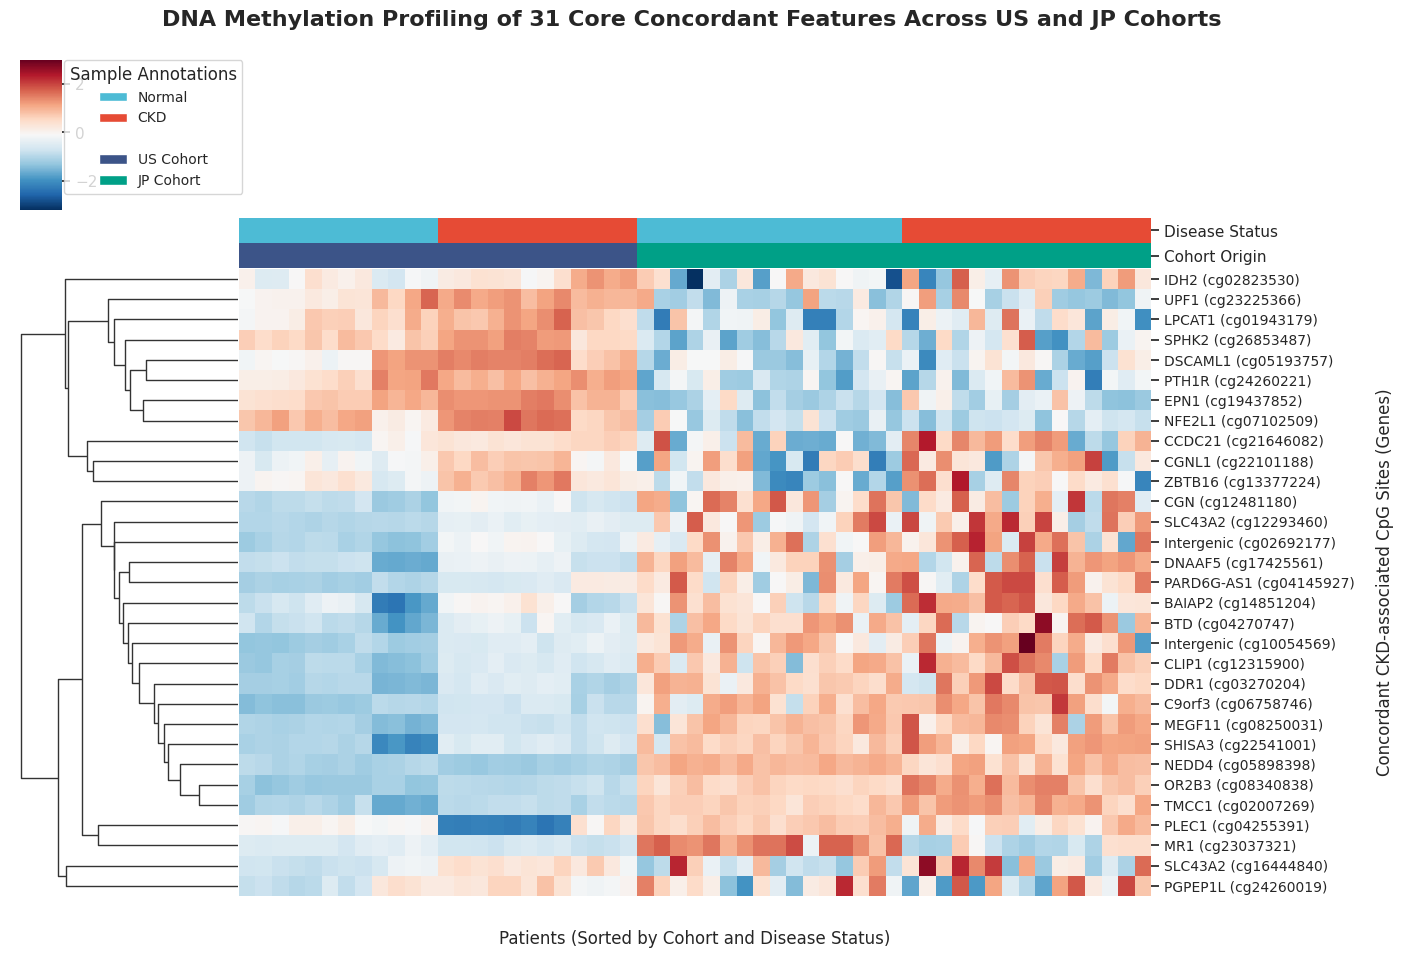

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

print("\n--- 繪製雙世代聯合熱圖 (Cross-Cohort Mega Heatmap) ---")

# 準備合併資料 (結合 US 與 JP)
X_us_plot = X_us_r[feats].copy()
X_us_plot['Status'] = ['CKD' if val == 1 else 'Normal' for val in y_us]
X_us_plot['Cohort'] = 'US'

X_jp_plot = X_jp_r[feats].copy()
X_jp_plot['Status'] = ['CKD' if val == 1 else 'Normal' for val in y_jp]
X_jp_plot['Cohort'] = 'JP'

# 合併成一張大表
plot_data_all = pd.concat([X_us_plot, X_jp_plot], axis=0)

# 排序樣本：先按 Cohort 排，再按 Status 排 (這會讓熱圖切分成完美的四個區塊)
plot_data_all = plot_data_all.sort_values(by=['Cohort', 'Status'], ascending=[False, False])

# 準備頂部雙層顏色標籤 (Column Colors)
status_pal = {'Normal': '#4DBBD5', 'CKD': '#E64B35'} # 藍色正常, 紅色疾病
cohort_pal = {'US': '#3C5488', 'JP': '#00A087'}      # 深藍美國, 墨綠日本

col_colors = pd.DataFrame({
    'Disease Status': plot_data_all['Status'].map(status_pal),
    'Cohort Origin': plot_data_all['Cohort'].map(cohort_pal)
})

# 準備 Y 軸基因標籤 (替換掉無意義的 cg 編號)
# 確保你前面有跑 summary，我們把 CpG ID 對應到 基因名稱
def get_display_name(cpg):
    gene_raw = summary.loc[summary['CpG'] == cpg, 'Gene'].values
    if len(gene_raw) > 0 and pd.notna(gene_raw[0]) and str(gene_raw[0]) != 'nan':
        gene_clean = str(gene_raw[0]).split(';')[0].strip()
        return f"{gene_clean} ({cpg})"
    return f"Intergenic ({cpg})"

# 將欄位名稱直接換成基因名稱
plot_data_all_features = plot_data_all[feats].rename(columns={c: get_display_name(c) for c in feats})

# 繪製 Clustermap
g = sns.clustermap(
    plot_data_all_features.T,
    cmap='RdBu_r',             # 藍白紅漸層 (最經典的表觀遺傳配色)
    col_colors=col_colors,     # 頂部加入雙層標籤
    col_cluster=False,         # 關閉行聚類，保持我們設定的 US/JP 完美分界
    row_cluster=True,          # 開啟列聚類，讓行為相似的基因靠在一起
    z_score=0,                 # 🌟 關鍵：列方向的 Z-score 標準化，極大化紅藍對比
    figsize=(14, 10),          # 加大圖表尺寸
    cbar_pos=(0.02, 0.82, 0.03, 0.15), # 調整 Colorbar 位置
    tree_kws={'linewidths': 1.0},
    yticklabels=True           # 顯示我們做好的基因標籤
)

# 微調字體與標題
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize=10, rotation=0)
g.ax_heatmap.set_xticklabels([]) # 隱藏底部的 X 軸樣本名稱 (太多了沒意義)
g.ax_heatmap.set_xlabel('Patients (Sorted by Cohort and Disease Status)', fontsize=12, labelpad=15)
g.ax_heatmap.set_ylabel('Concordant CKD-associated CpG Sites (Genes)', fontsize=12, labelpad=15)

g.fig.suptitle('DNA Methylation Profiling of 31 Core Concordant Features Across US and JP Cohorts',
               y=1.02, fontsize=16, fontweight='bold')

# 手動添加圖例 (Legend)
handles = [
    Patch(facecolor=status_pal['Normal'], label='Normal'),
    Patch(facecolor=status_pal['CKD'], label='CKD'),
    Patch(facecolor='white', label=''), # 空白佔位符
    Patch(facecolor=cohort_pal['US'], label='US Cohort'),
    Patch(facecolor=cohort_pal['JP'], label='JP Cohort')
]
plt.legend(handles=handles, title='Sample Annotations', bbox_to_anchor=(1.05, 1),
           loc='upper left', borderaxespad=0., frameon=True, fontsize=10, title_fontsize=12)

plt.show()